In [1]:
# Optotagging analysis: read a Phy-curated Kilosort 4 sorting (run on a
# concatenated behavior+optotagging recording, see notebook 2.2), split spikes
# back per session using session_boundaries.json, then classify units as
# opto-tagged using the laser events from the optotagging session.

In [1]:
from pathlib import Path
import yaml

# ======== parameters to change ========
session_name    = "IM-1979_2026-09-04"
base_dir_output = Path(r"E:/")
tagging_probe = "probeB"
kilosort_dir  = "kilosort4"                 # KS4 results subfolder name under <processed_session>/<tagging_probe>/
unit_criteria = {"quality": ["good"]}       # column -> criterion; see src.optotagging.load_curated_sorting
overwrite_summary = False                   # False = reuse optotagging_summary.csv if it already exists

opto_figures_mode = "plot"                  # "save" = all tagged units -> one PDF, no inline plots
                                            # "plot" = plot n_plot_preview random tagged units inline
n_plot_preview = 4
# ======================================

metadata_dir  = Path.cwd().parent
metadata_path = metadata_dir / "metadata" / f"{session_name}.yaml"
with open(metadata_path) as f:
    config = yaml.safe_load(f)

processed_path = base_dir_output / config["animal"] / "ephys" / config["sessions"]["processed"]
probe_names       = config["streams"]["probes"]

# The one probe to load + analyze for optotagging (must be Phy-curated already)
if tagging_probe not in probe_names:
    raise ValueError(f"tagging_probe={tagging_probe!r} not in this session's probes {probe_names}")

print(f"processed_session = {processed_path}")
print(f"tagging_probe     = {tagging_probe}  (available: {probe_names})")

processed_session = E:\D1-1-6_IM-1979\ephys\2026-09-04
tagging_probe     = probeB  (available: ['probeA', 'probeB'])


In [2]:
# ── load curated sorting for tagging_probe ──────────────────────────────────
import sys, json

sys.path.append('..')
from src import load_curated_sorting

sorting = load_curated_sorting(processed_path, tagging_probe, kilosort_dir=kilosort_dir,
                               unit_criteria=unit_criteria)

print(f"{tagging_probe}: {len(sorting.unit_ids)} units kept (unit_criteria={unit_criteria})")
display(sorting)

probeB: 406 units kept (unit_criteria={'quality': ['good']})


UnitsSelectionSorting: 406 units - 1 segments - 30.0kHz

In [3]:
# ── SANITY CHECK ONLY (not used by the optotagging analysis below) ──────────
# Split the concatenated sorting back per session via session_boundaries.json
# and check per-session firing rates look sane — confirms the sorting loaded
# and the concat-axis coordinate maths are right before we analyze anything.
import pandas as pd
from src import split_sorting_by_session

with open(processed_path / "session_boundaries.json") as f:
    session_boundaries = json.load(f)
sessions = session_boundaries["streams"][tagging_probe]["sessions"]
sorting_by_session = split_sorting_by_session(sorting, sessions)

fs = sorting.get_sampling_frequency()
quality_by_unit = dict(zip(sorting.unit_ids, sorting.get_property("quality")))

rows = []
for session in sessions:
    sid = session["session_id"]
    duration_s = (session["sample_end"] - session["sample_start"]) / fs
    for unit_id in sorting_by_session[sid].unit_ids:
        n_spikes = len(sorting_by_session[sid].get_unit_spike_train(unit_id))
        rows.append({"unit_id": unit_id, "session_id": sid,
                     "quality": quality_by_unit[unit_id], "n_spikes": n_spikes,
                     "firing_rate_hz": n_spikes / duration_s})
pd.DataFrame(rows).pivot(index=["unit_id", "quality"], columns="session_id",
                          values="firing_rate_hz")

,session_id,behavior,optotagging
unit_id,quality,,
2,good,1.102483,0.038172
3,good,1.006455,0.507979
7,good,0.231127,0.156602
8,good,0.257512,0.387591
9,good,2.157649,2.309885
...,...,...,...
860,good,0.240768,0.935699
867,good,0.618791,1.076641
868,good,0.055815,0.195753


In [4]:
# ── load laser events (+ per-block power from the protocol csv) ─────────────
import pandas as pd
from src import (load_laser_events, load_laser_protocol,
                 annotate_laser_events_with_protocol, compute_population_opto_response)

# NOTE: use the unsliced `sorting` (concatenated-axis sample indices), not
# sorting_by_session["optotagging"] — laser_events.csv's on_sample_concat is
# in that same concatenated-axis coordinate system (see src.optotagging
# module docstring / load_laser_events).
laser_events = load_laser_events(processed_path, probe_name=tagging_probe, session_id="optotagging")

protocol = load_laser_protocol(processed_path / "laser_control_protocol_dual_mega2560.csv")
laser_events = annotate_laser_events_with_protocol(laser_events, protocol)
print(laser_events.groupby(["color", "block", "power"]).size())

# opto_df: one row per (unit, color, power) — each power level tested for
# significance separately. `is_tagged` = that (unit, color, power) group passed;
# `color_tagged` = the unit is tagged for that colour at >= 1 of its powers.
summary_path = processed_path / tagging_probe / "optotagging_summary.csv"
if summary_path.exists() and not overwrite_summary:
    print(f"\nreusing existing {summary_path.name} (set overwrite_summary=True to recompute)")
    opto_df = pd.read_csv(summary_path)
else:
    opto_df = compute_population_opto_response(sorting, laser_events)   # by=("color", "power")
    opto_df.to_csv(summary_path, index=False)
    print(f"\nwrote {summary_path}")

color_tagged = opto_df[["unit_id", "color", "color_tagged"]].drop_duplicates()
print(f"{opto_df['is_tagged'].sum()} / {len(opto_df)} (unit, color, power) groups tagged")
print(f"{color_tagged['color_tagged'].sum()} (unit, color) tagged at >= 1 power level")
opto_df[opto_df["is_tagged"]].sort_values("reliability", ascending=False)

color       block  power
blue_laser  0      1 mW     100
            1      5 mW     100
            2      10 mW    100
            3      20 mW    100
red_laser   0      1 mW     100
            1      5 mW     100
            2      10 mW    100
            3      20 mW    100
dtype: int64

reusing existing optotagging_summary.csv (set overwrite_summary=True to recompute)
191 / 3248 (unit, color, power) groups tagged
84 (unit, color) tagged at >= 1 power level


,unit_id,color,power,is_tagged,n_trials,n_responded,reliability,latency_ms,median_latency_ms,jitter_ms,salt_p,salt_stat,color_tagged
257,527,blue_laser,1 mW,True,100,100,1.00,3.357333,3.350000,0.834360,0.0,1.137402,True
524,228,blue_laser,5 mW,True,100,100,1.00,2.720333,2.700000,0.581529,0.0,1.175877,True
663,527,blue_laser,5 mW,True,100,100,1.00,2.197000,2.100000,0.730420,0.0,1.137864,True
930,228,blue_laser,10 mW,True,100,100,1.00,2.214000,2.216667,0.211407,0.0,1.177410,True
1336,228,blue_laser,20 mW,True,100,100,1.00,1.818000,1.800000,0.390482,0.0,1.177410,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,837,blue_laser,10 mW,True,100,26,0.26,5.382051,4.883333,1.680945,0.0,0.427887,True
1161,700,blue_laser,10 mW,True,100,26,0.26,6.265385,6.416667,2.190900,0.0,0.438160,True
1156,688,blue_laser,10 mW,True,100,26,0.26,6.251282,6.933333,2.357299,0.0,0.409093,True
1517,620,blue_laser,20 mW,True,100,26,0.26,3.857692,3.516667,2.044370,0.0,0.443959,True


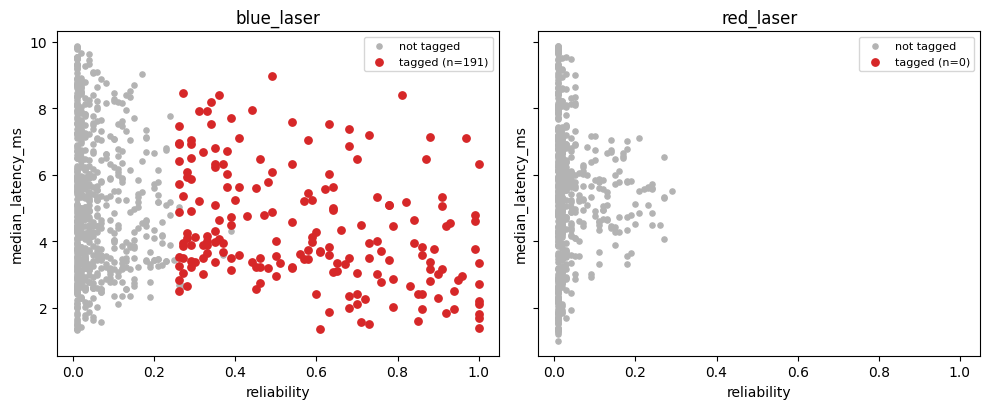

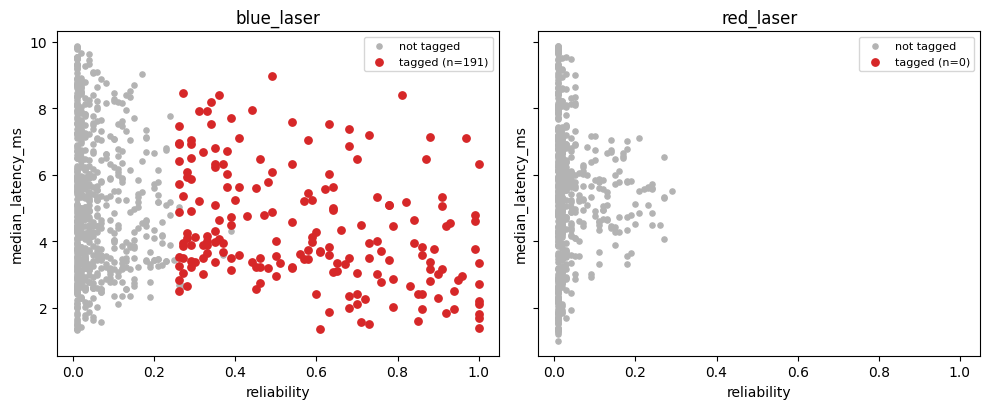

In [5]:
# ── population overview: reliability vs latency, tagged units highlighted ────
%matplotlib inline
from src import plot_opto_response, plot_opto_population

plot_opto_population(opto_df)

In [7]:
# ── per-unit raster + PSTH for the tagged units ────────────────────────────
#   opto_figures_mode == "plot" : plot n_plot_preview random tagged units inline
#   opto_figures_mode == "save" : save every tagged unit to one multi-page PDF
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

opto_figures_mode = "save"  # "plot" or "save"

tagged_unit_ids = (opto_df[opto_df["is_tagged"]]
                   .sort_values("reliability", ascending=False)["unit_id"].drop_duplicates().tolist())
print(f"{len(tagged_unit_ids)} tagged units")

if opto_figures_mode == "plot":
    for unit_id in random.sample(tagged_unit_ids, k=min(n_plot_preview, len(tagged_unit_ids))):
        plot_opto_response(sorting, laser_events, unit_id)

elif opto_figures_mode == "save":
    pdf_path = processed_path / tagging_probe / "optotagging_figures.pdf"
    with PdfPages(pdf_path) as pdf:
        for unit_id in tagged_unit_ids:                 # highest reliability first
            fig = plot_opto_response(sorting, laser_events, unit_id)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    print(f"saved {len(tagged_unit_ids)} pages to {pdf_path}")

else:
    raise ValueError(f"opto_figures_mode must be 'plot' or 'save', got {opto_figures_mode!r}")

84 tagged units
saved 84 pages to E:\D1-1-6_IM-1979\ephys\2026-09-04\probeB\optotagging_figures.pdf
